In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

In [2]:
pd.set_option('display.max_columns',None)
url = 'https://raw.githubusercontent.com/ichiP245/my-next-soderling/refs/heads/main/Archivos/pre_ml_df.csv'

df = pd.read_csv(url)
df['Fecha'] = pd.to_datetime(df['Fecha'], format='%Y-%m-%d')

In [3]:
random_state=42

## Calculo de ELO

In [4]:
def calcular_elo(df, k=32, elo_inicial=1500):
    """
    df debe estar ordenado temporalmente y tener columnas:
    - 'playerA', 'playerB', 'target' (1 si gana A, 0 si gana B)
    """
    elo = {}  # diccionario jugador -> elo actual

    elo_A_antes = []
    elo_B_antes = []

    for _, row in df.iterrows():
        a = row['playerA']
        b = row['playerB']

        # Inicializar si es la primera vez que aparece el jugador
        if a not in elo:
            elo[a] = elo_inicial
        if b not in elo:
            elo[b] = elo_inicial

        # Guardar ELO ANTES del partido (para usar como feature)
        elo_A_antes.append(elo[a])
        elo_B_antes.append(elo[b])

        # Probabilidad esperada según ELO
        expected_A = 1 / (1 + 10 ** ((elo[b] - elo[a]) / 400))
        expected_B = 1 - expected_A

        # Resultado real
        score_A = row['target']       # 1 si ganó A, 0 si perdió
        score_B = 1 - row['target']

        # Actualizar ELO
        elo[a] = elo[a] + k * (score_A - expected_A)
        elo[b] = elo[b] + k * (score_B - expected_B)

    df['elo_A'] = elo_A_antes
    df['elo_B'] = elo_B_antes
    df['elo_diff'] = df['elo_A'] - df['elo_B']

    return df, elo

In [5]:
def calcular_elo_superficie(df, k=24, elo_inicial=1500):
    elo_superficie = {}  # (jugador, superficie) -> elo

    elo_A_surf, elo_B_surf = [], []

    for _, row in df.iterrows():
        a   = row['playerA']
        b   = row['playerB']
        sup = row['Surface']

        # Arranca desde ELO global si es la primera vez en esa superficie
        if (a, sup) not in elo_superficie:
            elo_superficie[(a, sup)] = row['elo_A']  # usás el elo global ya calculado
        if (b, sup) not in elo_superficie:
            elo_superficie[(b, sup)] = row['elo_B']

        elo_A_surf.append(elo_superficie[(a, sup)])
        elo_B_surf.append(elo_superficie[(b, sup)])

        exp_A = 1 / (1 + 10 ** ((elo_superficie[(b, sup)] - elo_superficie[(a, sup)]) / 400))

        score_A = row['target']
        elo_superficie[(a, sup)] += k * (score_A - exp_A)
        elo_superficie[(b, sup)] += k * ((1 - score_A) - (1 - exp_A))

    df = df.copy()
    df['elo_surf_A']          = elo_A_surf
    df['elo_surf_B']          = elo_B_surf
    df['elo_surf_diff']       = df['elo_surf_A'] - df['elo_surf_B']
    df['elo_surf_adv_A']      = df['elo_surf_A'] - df['elo_A']  # especialista en superficie
    df['elo_surf_adv_B']      = df['elo_surf_B'] - df['elo_B']
    df['elo_surf_adv_diff']   = df['elo_surf_adv_A'] - df['elo_surf_adv_B']

    return df

In [6]:
df, elo = calcular_elo(df, k=45)

In [7]:
df = calcular_elo_superficie(df.sort_values('Fecha'), k=45)

## Encoding de categóricas

Como el objetivo es que estos datos entren a un modelo de Machine Learning, le hacemos un encoding a las variables categóricas.

Para eso exploramos un poco esas variables. Sin embargo, para análisis exploratorio multivariable usaremos el df que acabamos de guardar, ya que tiene estas variables no encodeadas y eso nos va a facilitar el análisis para tal caso.

Para el nivel del torneo podemos hacer un OrdinalEncoder tranquilamente

In [9]:
df['Series'].value_counts()

,count
Series,
Masters 1000,5884
Grand Slam,5459
ATP500,3954
ATP250,764


In [10]:
from sklearn.preprocessing import OrdinalEncoder # Ordinal Encoder -> con valores de 0 a n cantidad de variables

oe = OrdinalEncoder(categories=[['ATP250', 'ATP500', 'Masters 1000', 'Grand Slam']])
series_oe = oe.fit_transform(df[['Series']])
series_oe = pd.DataFrame(series_oe, columns=['series_level_oe'])
df = pd.concat([df, series_oe], axis=1)

Para Round armamos varias One Hot, porque tenemos ['1st Round', '2nd Round', 'Quarterfinals', 'Semifinals', 'The Final', '3rd Round', '4th Round'] y no sirve hacer un solo OneHot o un LabelEncoder ni otro.

Entonces encodeamos las instancias que son mas importantes: si es o no una final, si es o no una semifinal (donde puede llegar alguno que hizo un batacazo y eso puede influenciar) y si es o no 1st round

In [11]:
df['Round'].value_counts()

,count
Round,
1st Round,7252
2nd Round,4541
3rd Round,1768
Quarterfinals,1096
4th Round,583
Semifinals,548
The Final,273


In [12]:
round_order = {
    '1st Round': 1, '2nd Round': 2, '3rd Round': 3,
    '4th Round': 4, 'Quarterfinals': 5, 'Semifinals': 6, 'The Final': 7
}

df['round_encoded'] = df['Round'].map(round_order)

"Best of" es numerica pero categorica. Le hacemos One Hot

In [13]:
df['Best of'].value_counts()

,count
Best of,
3.0,10612
5.0,5449


In [14]:
df['is_best_of_5'] = (df['Best of'] == 5).astype(int)

Para Surface = ['Hard', 'Clay', 'Grass'] usamos FrequencyEncoder

In [15]:
df['Surface'].value_counts(normalize=True)

,proportion
Surface,
Hard,0.608617
Clay,0.293008
Grass,0.098375


In [16]:
surface_fe = df['Surface'].value_counts(normalize=True) # Generamos un pd.Series con la proporcion de cada valor unicos
df['surface_fe'] = df['Surface'].map(surface_fe)  # Armamos una variable donde cada valor recibe la frecuencia de aparicion de ese valor unico

Para Court = ['Outdoor', 'Indoor'] usamos OneHotEncoder

In [17]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(sparse_output=False, drop='first')
court_encoded = ohe.fit_transform(df[['Court']])
court_encoded = pd.DataFrame(court_encoded, columns=ohe.get_feature_names_out()).rename(columns={'Court_Outdoor':'is_outdoor'})
df = pd.concat([df, court_encoded], axis=1)

## Más Feature Engineering

Esta celda la corremos ahora pero no para guardar el df

In [ ]:
weather_cols = ['temperature_2m_mean',
       'apparent_temperature_mean', 'precipitation_sum', 'rain_sum',
       'wind_speed_10m_max', 'wind_gusts_10m_max', 'wind_gusts_10m_mean',
       'wind_speed_10m_mean', 'relative_humidity_2m_mean',
       'relative_humidity_2m_max', 'relative_humidity_2m_min',
       'soil_temperature_0_to_100cm_mean', 'soil_moisture_0_to_100cm_mean',
       'wind_gusts_10m_min', 'wind_speed_10m_min']

In [ ]:
for col in weather_cols:
    df[col] = df[col]*df['is_outdoor']

Seguimos acá

In [18]:
# Consenso de probabilidad entre casas (A qué tan de acuerdo están)
df['prob_consensus_A'] = (df['B365ProbA'] + df['ProbAvgA'] + df['ProbMaxA']) / 3

# Dispersión entre casas → incertidumbre de mercado más fina
df['bookmaker_std_A'] = df[['B365ProbA', 'ProbAvgA', 'ProbMaxA']].std(axis=1)

# Ratio de probabilidades (más informativo que la diferencia en extremos)
df['prob_ratio_B365'] = df['B365ProbA'] / df['B365ProbB']

# "Desacuerdo" entre B365 y el promedio del mercado
df['b365_vs_market'] = df['B365ProbA'] - df['ProbAvgA']

# Ratio en lugar de diferencia (rankDiff de 10 no es igual si es 1vs11 que 100vs110)
df['rankRatio'] = df['rankA'] / df['rankB']
df['log_rankDiff'] = np.log(df['rankA'] + 1) - np.log(df['rankB'] + 1)

# Nivel del partido (¿es un partido entre top players?)
df['rank_sum'] = df['rankA'] + df['rankB']
df['ptsRatio'] = df['PtsA'] / (df['PtsA'] + df['PtsB'])

# ¿Está mejorando o decayendo en los últimos partidos?
df['momentum_A'] = df['winrate_5_A'] - df['winrate_10_A']
df['momentum_B'] = df['winrate_5_B'] - df['winrate_10_B']
df['diff_momentum']  = df['momentum_A'] - df['momentum_B']

# Intensidad de actividad reciente
df['sets_per_day_30d_A'] = df['sets_30d_A'] / (df['dias_ultimo_partido_A'] + 1)
df['sets_per_day_30d_B'] = df['sets_30d_B'] / (df['dias_ultimo_partido_B'] + 1)
df['diff_sets_per_day'] = df['sets_per_day_30d_A'] - df['sets_per_day_30d_B']

# En best-of-5, el ranking y la forma pesan más
df['bo5_rank_diff']     = df['is_best_of_5'] * df['rankDiff']
df['bo5_momentum_diff'] = df['is_best_of_5'] * df['diff_momentum']

Guardamos el df

In [20]:
df.to_csv('encoded_plus_df.csv', index=False)

## Sigue preparación para ML

Volvemos a guardar el df

In [ ]:
columns_drop = ['Series', 'Court', 'Surface', 'Round', 'Best of']

In [ ]:
df = df.drop(columns=columns_drop)

Sacamos columnas que revelan información

In [ ]:
new_df = df.drop(columns=['Location', 'Fecha', 'playerA', 'playerB',
                          'A1', 'B1', 'A2', 'B2', 'A3', 'B3', 'A4', 'B4', 'A5',
                          'B5', 'setsA', 'setsB', 'setsPartido'])

Eliminamos nulos

In [ ]:
df_no_nulls = new_df.dropna()

Separamos conjuntos

In [ ]:
X = df_no_nulls.drop(columns=['target'])
y = df_no_nulls['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=random_state)

## Modelo 0: baseline

In [ ]:
# Nivel 1 — Mayoría simple (lower bound absoluto)
majority_class = y_train.mode()[0]
baseline_majority = np.full(len(y_test), majority_class)

# Nivel 2 — Tu baseline de ranking (naive sports knowledge)
y_baseline_rank = (X_test['rankA'] < X_test['rankB']).astype(int)

# Nivel 3 — Baseline de odds (upper bound)
y_baseline_odds = (X_test['B365ProbA'] > 0.5).astype(int)

for name, pred in [("Mayoría", baseline_majority),
                   ("Ranking", y_baseline_rank),
                   ("Odds B365", y_baseline_odds)]:
    print(f"{name}: {accuracy_score(y_test, pred)}")

Mayoría: 0.5157860824742269
Ranking: 0.6710695876288659
Odds B365: 0.7313144329896907


Vemos confusion matrix para cada caso

In [ ]:
print('Matriz de confusion para baseline mayoría:')
print(confusion_matrix(y_test, baseline_majority))

print('Matriz de confusion para baseline ranking:')
print(confusion_matrix(y_test, y_baseline_rank))

print('Matriz de confusion para baseline odds:')
print(confusion_matrix(y_test, y_baseline_odds))

Matriz de confusion para baseline mayoría:
[[1601    0]
 [1503    0]]
Matriz de confusion para baseline ranking:
[[1064  537]
 [ 484 1019]]
Matriz de confusion para baseline odds:
[[1172  429]
 [ 405 1098]]


## Modelo 1: Logistic Regression

In [ ]:
logreg = LogisticRegression(fit_intercept=False,random_state=42)
logreg.fit(X_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(fit_intercept=False, random_state=42)

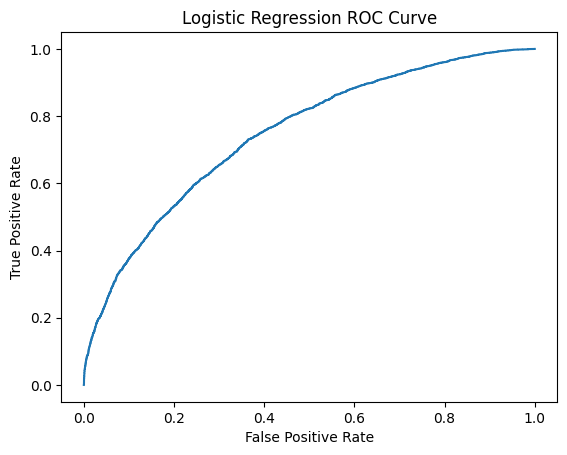

In [ ]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_train, logreg.predict_proba(X_train)[:, 1])
#plt.plot([0, 1], [0, 1], 'k--')
plt.plot(fpr, tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Logistic Regression ROC Curve')
plt.show()

In [ ]:
from sklearn.metrics import roc_auc_score
print(roc_auc_score(y_train, logreg.predict_proba(X_train)[:, 1]))

0.7468015904513718


In [ ]:
y_logreg = logreg.predict(X_test)

In [ ]:
print('Matriz de confusion para Logistic Regression:')
print(confusion_matrix(y_test, y_logreg))

print('Reporte de clasificación para Logistic Regression:')
print(classification_report(y_test, y_logreg))

Matriz de confusion para Logistic Regression:
[[1121  480]
 [ 470 1033]]
Reporte de clasificación para Logistic Regression:
              precision    recall  f1-score   support

           0       0.70      0.70      0.70      1601
           1       0.68      0.69      0.69      1503

    accuracy                           0.69      3104
   macro avg       0.69      0.69      0.69      3104
weighted avg       0.69      0.69      0.69      3104



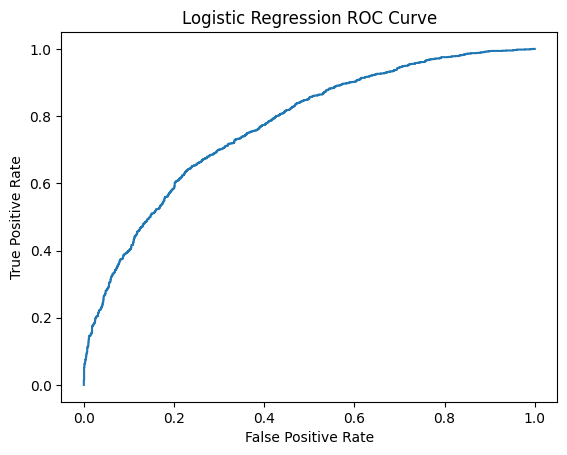

In [ ]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, logreg.predict_proba(X_test)[:, 1])
#plt.plot([0, 1], [0, 1], 'k--')
plt.plot(fpr, tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Logistic Regression ROC Curve')
plt.show()

In [ ]:
from sklearn.metrics import roc_auc_score
print(roc_auc_score(y_test, logreg.predict_proba(X_test)[:, 1]))

0.772102302304548


## Modelo 2: Logistic Regression Optimized

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

param_grid = {
    'logistic__C'          : np.logspace(-3, 3, 20),  # Regularización
    'logistic__penalty'    : ['l1', 'l2'],
    'logistic__solver'     : ['liblinear'],
}

pipeline = Pipeline([
    ('scaler',   StandardScaler()),
    ('logistic', LogisticRegression(max_iter=1000, random_state=42))
])

search_lr = RandomizedSearchCV(
    estimator           = pipeline,
    param_distributions = param_grid,
    n_iter              = 30,
    cv                  = 5,
    scoring             = 'roc_auc',
    n_jobs              = 1,
    random_state        = 42,
    verbose             = 2
)

search_lr.fit(X_train, y_train)

print(f"Mejores parámetros: {search_lr.best_params_}")
print(f"Mejor ROC-AUC: {search_lr.best_score_:.4f}")

modelo_lr = search_lr.best_estimator_

Fitting 5 folds for each of 30 candidates, totalling 150 fits
[CV] END logistic__C=0.6951927961775606, logistic__penalty=l2, logistic__solver=liblinear; total time=   1.1s
[CV] END logistic__C=0.6951927961775606, logistic__penalty=l2, logistic__solver=liblinear; total time=   0.7s
[CV] END logistic__C=0.6951927961775606, logistic__penalty=l2, logistic__solver=liblinear; total time=   0.7s
[CV] END logistic__C=0.6951927961775606, logistic__penalty=l2, logistic__solver=liblinear; total time=   0.6s
[CV] END logistic__C=0.6951927961775606, logistic__penalty=l2, logistic__solver=liblinear; total time=   1.1s
[CV] END logistic__C=0.3359818286283781, logistic__penalty=l1, logistic__solver=liblinear; total time=   2.4s
[CV] END logistic__C=0.3359818286283781, logistic__penalty=l1, logistic__solver=liblinear; total time=   0.7s
[CV] END logistic__C=0.3359818286283781, logistic__penalty=l1, logistic__solver=liblinear; total time=   0.7s
[CV] END logistic__C=0.3359818286283781, logistic__penalty

## Modelo 2 bis: Logistic simplificado

In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr.fit(X_train[['B365ProbA', 'diff_winrate_5', 'diff_sets_30d','market_uncertainty', 'b365_vs_market']], y_train)

LogisticRegression()

In [ ]:
y_pred_log_simpl = lr.predict(X_test[['B365ProbA', 'diff_winrate_5', 'diff_sets_30d','market_uncertainty', 'b365_vs_market']])

In [ ]:
accuracy_score(y_test, y_pred_log_simpl)

0.7322809278350515

## Modelo 3: DecisionTree

In [ ]:
from sklearn.tree import DecisionTreeClassifier

tree_clf = DecisionTreeClassifier(max_depth=50, min_samples_leaf=10, max_leaf_nodes=100, random_state=42)
tree_clf.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=50, max_leaf_nodes=100, min_samples_leaf=10,
                       random_state=42)

In [ ]:
# from sklearn.tree import plot_tree
# plt.figure(figsize=(10, 8))

# plot_tree(tree_clf,
#           feature_names=X_train.columns,
#           class_names=['Gana B', 'Gana A'],
#           rounded=True,
#           filled=True)
# plt.show()

In [ ]:
print('Profundidad del árbol:', tree_clf.get_depth())                    # Profundidad
print('Número de nodos terminales (hoja): ', tree_clf.get_n_leaves())    # Cantidad de nodos hoja

Profundidad del árbol: 23
Número de nodos terminales (hoja):  100


In [ ]:
y_tree_clf = tree_clf.predict(X_test)

In [ ]:
accuracy_score(y_test, y_tree_clf)

0.7029639175257731

In [ ]:
print(confusion_matrix(y_test, tree_clf.predict(X_test)))

[[1096  505]
 [ 417 1086]]


## Modelo 4: RandomForest

In [ ]:
rnd_clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,          # limitar profundidad, el más importante
    min_samples_leaf=30,  # cada hoja necesita al menos 30 partidos
    min_samples_split=50, # para splitear un nodo necesita 50 muestras
    max_features='sqrt',  # ya lo hace por default, pero explicitarlo
    random_state=42
)
rnd_clf.fit(X_train, y_train)

RandomForestClassifier(max_depth=6, min_samples_leaf=30, min_samples_split=50,
                       n_estimators=200, random_state=42)

In [ ]:
y_pred_rf_test = rnd_clf.predict(X_test)

In [ ]:
print('Matriz de confusión de datos de test:')
print(confusion_matrix(y_test, y_pred_rf_test))

print('Classification report de datos de test:')
print(classification_report(y_test, y_pred_rf_test))

Matriz de confusión de datos de test:
[[1150  451]
 [ 386 1117]]
Classification report de datos de test:
              precision    recall  f1-score   support

           0       0.75      0.72      0.73      1601
           1       0.71      0.74      0.73      1503

    accuracy                           0.73      3104
   macro avg       0.73      0.73      0.73      3104
weighted avg       0.73      0.73      0.73      3104



In [ ]:
# Diagnóstico rápido
print("Train accuracy:", rnd_clf.score(X_train, y_train))
print("Test accuracy: ", rnd_clf.score(X_test, y_test))
print("Odds baseline: ", accuracy_score(y_test, (X_test['B365ProbA'] > 0.5).astype(int)))

Train accuracy: 0.7156783757653883
Test accuracy:  0.7303479381443299
Odds baseline:  0.7313144329896907


Importancias de las features

In [ ]:
importances = rnd_clf.feature_importances_
features = X.columns
feature_importances = pd.DataFrame({'feature': features, 'importance': importances}).sort_values('importance', ascending=False)

In [ ]:
pd.concat([feature_importances.head(20).reset_index(drop=True).rename(columns={'feature': 'top_20'}), feature_importances.tail(20).reset_index(drop=True).rename(columns={'feature': 'bottom_20'})], axis=1)

,top_20,importance,bottom_20,importance
0,ProbMaxA,0.082939,sets_30d_A,0.000792
1,prob_consensus_A,0.074772,winrate_10_B,0.000642
2,ProbMaxB,0.062098,bo5_rank_diff,0.000611
3,ProbAvgA,0.059207,diff_winrate_10,0.000597
4,AvgOddsDiff,0.051419,winrate_5_B,0.000568
5,MaxA,0.051093,momentum_A,0.000524
6,logit_oddsB,0.045282,diff_winrate_5,0.000512
7,ProbAvgB,0.044573,sets_5d_B,0.000510
8,logit_oddsA,0.040678,winrate_5_A,0.000470
9,OddsDiffAvg,0.038483,sets_5d_A,0.000456


Examinamos su está bien calibrado o no el predictor

In [ ]:
from sklearn.calibration import calibration_curve

# Probabilidades de tu modelo
proba = rnd_clf.predict_proba(X_test)[:, 1]

# ¿Cuándo tu modelo dice 0.7 y las odds dicen 0.5, quién tiene razón?
df_test = X_test.copy()
df_test['y_true'] = y_test.values
df_test['proba_modelo'] = proba
df_test['proba_odds'] = df_test['B365ProbA']

# Partidos donde tu modelo y las odds difieren más
df_test['desacuerdo'] = (df_test['proba_modelo'] - df_test['proba_odds']).abs()
df_test.sort_values('desacuerdo', ascending=False).head(20)

,rankA,rankB,PtsA,PtsB,B365A,B365B,MaxA,MaxB,AvgA,AvgB,B365BookmakersMargin,B365ProbA,B365ProbB,ProbAvgA,ProbAvgB,ProbMaxA,ProbMaxB,market_uncertainty,OddsDiffB365,OddsDiffAvg,OddsDiffMax,AvgOddsDiff,logit_oddsA,logit_oddsB,rankDiff,ptsDiff,winrate_5_A,winrate_10_A,wins_before_A,win_pct_before_A,sets_5d_A,sets_30d_A,partidos_365d_A,dias_ultimo_partido_A,racha_victorias_A,winrate_5_B,winrate_10_B,wins_before_B,win_pct_before_B,sets_5d_B,sets_30d_B,partidos_365d_B,dias_ultimo_partido_B,racha_victorias_B,diff_winrate_5,diff_winrate_10,diff_win_pct_before,diff_sets_5d,diff_sets_30d,diff_dias_ultimo_partido,diff_partidos_365d,h2h_matches_previous,temperature_2m_mean,apparent_temperature_mean,precipitation_sum,rain_sum,wind_speed_10m_max,wind_gusts_10m_max,wind_gusts_10m_mean,wind_speed_10m_mean,relative_humidity_2m_mean,relative_humidity_2m_max,relative_humidity_2m_min,soil_temperature_0_to_100cm_mean,soil_moisture_0_to_100cm_mean,wind_gusts_10m_min,wind_speed_10m_min,elo_A,elo_B,elo_diff,elo_surf_A,elo_surf_B,elo_surf_diff,elo_surf_adv_A,elo_surf_adv_B,elo_surf_adv_diff,series_level_oe,round_encoded,is_best_of_5,surface_fe,is_outdoor,prob_consensus_A,bookmaker_std_A,prob_ratio_B365,b365_vs_market,rankRatio,log_rankDiff,rank_sum,ptsRatio,momentum_A,momentum_B,diff_momentum,sets_per_day_30d_A,sets_per_day_30d_B,diff_sets_per_day,bo5_rank_diff,bo5_momentum_diff,y_true,proba_modelo,proba_odds,desacuerdo
9036,93.0,1.0,839.0,11313.0,0.967,29.00,34.00,1.01,21.85,1.01,0.068609,0.967731,0.032269,0.044182,0.955818,0.028849,0.971151,0.455818,-28.033,20.84,32.99,-0.911636,-3.074251,3.074251,92.0,-10474.0,0.6,0.6,25.0,0.357143,8.0,8.0,15,2.0,2,0.800000,0.800000,304.0,0.876081,6.0,19.0,40,2.0,2,-0.200000,-0.200000,-0.518938,2.0,-11.0,0.0,-25,2,16.502085,14.970299,0.300000,0.300000,18.626305,36.719997,27.210001,14.331012,74.148970,92.813835,54.611290,15.303981,0.232037,14.400000,8.049845,1566.427409,2101.335654,-534.908246,1478.822355,1969.889033,-491.066678,-87.605054,-131.446621,43.841567,3.0,3,1,0.293008,1.0,0.346921,0.537692,29.989659,0.923549,93.000000,3.850148,94.0,0.069042,0.0,0.0,0.0,2.666667,6.333333,-3.666667,92.0,0.0,0,0.207331,0.967731,0.760400
2530,2.0,7.0,8915.0,3175.0,1.250,4.33,4.36,1.30,3.97,1.26,0.030947,0.775986,0.224014,0.240918,0.759082,0.229682,0.770318,0.259082,-3.080,2.71,3.06,-0.518164,-1.147654,1.147654,-5.0,5740.0,1.0,0.9,89.0,0.824074,8.0,20.0,61,2.0,6,1.000000,0.900000,52.0,0.732394,9.0,23.0,45,2.0,6,0.000000,0.000000,0.091680,-1.0,-3.0,0.0,16,3,17.520500,15.761944,0.200000,0.200000,27.059933,50.760000,41.324993,21.809044,81.931390,91.111336,63.508724,16.243145,0.334862,32.760002,17.238699,2047.893190,1873.144877,174.748313,1907.215221,1779.119212,128.096008,-140.677969,-94.025664,-46.652305,3.0,7,1,0.098375,1.0,0.415528,0.312216,3.464000,0.535068,0.285714,-0.980829,9.0,0.737386,0.1,0.1,0.0,6.666667,7.666667,-1.000000,-5.0,0.0,1,0.302189,0.775986,0.473797
10434,96.0,43.0,668.0,1070.0,4.000,1.25,2.31,1.75,2.16,1.69,0.050000,0.238095,0.761905,0.438961,0.561039,0.431034,0.568966,0.061039,2.750,0.47,0.56,-0.122078,-0.245380,0.245380,53.0,-402.0,0.2,0.3,12.0,0.352941,0.0,0.0,12,59.0,0,0.200000,0.400000,20.0,0.454545,0.0,5.0,23,14.0,0,0.000000,-0.100000,-0.101604,0.0,-5.0,45.0,-11,1,13.495834,11.174495,6.000000,6.000000,20.037485,36.000000,27.630000,14.158750,73.980930,91.695500,53.230850,16.401834,0.259210,9.720000,4.735060,1486.009552,1580.126802,-94.117250,1495.193508,1440.961560,54.231948,9.183956,-139.165242,148.349198,3.0,1,1,0.293008,1.0,0.369364,0.113751,0.312500,-0.200866,2.232558,0.790521,139.0,0.384350,-0.1,-0.2,0.1,0.000000,0.333333,-0.333333,53.0,0.1,1,0.378595,0.238095,0.140500
376,1.0,2.0,13205.0,9205.0,1.500,2.62,1.55,2.90,1.49,2.60,0.048346,0.635922,0.364078,0.635697,0.364303,0.651685,0.348315,0.135697,-1.120,-1.11,-1.35,0.271394,0.556735,-0.556735,-1.0,4000.0,1.0,0.9,18.0,0.900000,6.0,19.0,20,1.0,5,1.000000,1.000000,12.0,0.923077,8.0,19.0,13,1.0,10,0.000000,-0.100000,-0.023077,-2.0,0.0,0.0,7,1,20.664835,1

Curva de calibración: lo importante es estar lo más cerca de la curva posible.

- "If a model predicts a probability of p, then p proportion of the events should actually occur."

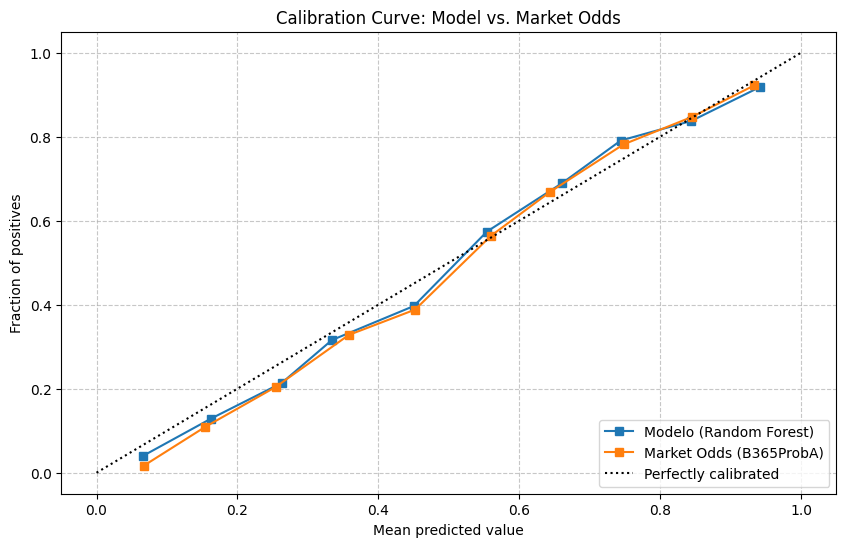

In [ ]:
from sklearn.calibration import calibration_curve

plt.figure(figsize=(10, 6))

# Calibración del modelo
fraction_of_positives_model, mean_predicted_value_model = calibration_curve(
    df_test['y_true'], df_test['proba_modelo'], n_bins=10
)
plt.plot(
    mean_predicted_value_model, fraction_of_positives_model, "s-",
    label=f"Modelo (Random Forest)"
)

# Calibración de las odds del mercado
fraction_of_positives_odds, mean_predicted_value_odds = calibration_curve(
    df_test['y_true'], df_test['proba_odds'], n_bins=10
)
plt.plot(
    mean_predicted_value_odds, fraction_of_positives_odds, "s-",
    label=f"Market Odds (B365ProbA)"
)

# Línea de calibración perfecta
plt.plot([0, 1], [0, 1], "k:", label="Perfectly calibrated")

plt.xlabel("Mean predicted value")
plt.ylabel("Fraction of positives")
plt.title("Calibration Curve: Model vs. Market Odds")
plt.legend(loc="lower right")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [ ]:
# Define probability bins
bins = np.linspace(0, 1, 6) # e.g., [0, 0.2, 0.4, 0.6, 0.8, 1.0]

print("Brier Score comparison per probability bin:")
print("---------------------------------------------------")
for i in range(len(bins) - 1):
    lower_bound = bins[i]
    upper_bound = bins[i+1]

    # Filter data for the current bin based on model's predicted probability
    bin_df = df_test[
        (df_test['proba_modelo'] >= lower_bound) &
        (df_test['proba_modelo'] < upper_bound)
    ]

    if len(bin_df) == 0:
        print(f"Bin [{lower_bound:.1f}, {upper_bound:.1f}): No data")
        continue

    brier_model_bin = brier_score_loss(bin_df['y_true'], bin_df['proba_modelo'])
    brier_odds_bin  = brier_score_loss(bin_df['y_true'], bin_df['proba_odds'])

    print(f"Bin [{lower_bound:.1f}, {upper_bound:.1f}):")
    print(f"  Model Brier Score: {brier_model_bin:.4f}")
    print(f"  Market Brier Score: {brier_odds_bin:.4f}")
    if brier_model_bin < brier_odds_bin:
        print("  -> Model is more reliable in this range.")
    elif brier_model_bin > brier_odds_bin:
        print("  -> Market is more reliable in this range.")
    else:
        print("  -> Both are similarly reliable in this range.")
    print()


Brier Score comparison per probability bin:
---------------------------------------------------
Bin [0.0, 0.2):
  Model Brier Score: 0.0801
  Market Brier Score: 0.0815
  -> Model is more reliable in this range.

Bin [0.2, 0.4):
  Model Brier Score: 0.1852
  Market Brier Score: 0.1870
  -> Model is more reliable in this range.

Bin [0.4, 0.6):
  Model Brier Score: 0.2433
  Market Brier Score: 0.2432
  -> Market is more reliable in this range.

Bin [0.6, 0.8):
  Model Brier Score: 0.1819
  Market Brier Score: 0.1824
  -> Model is more reliable in this range.

Bin [0.8, 1.0):
  Model Brier Score: 0.1137
  Market Brier Score: 0.1145
  -> Model is more reliable in this range.



### Brier Score Explanation

The Brier Score is a quadratic scoring rule that measures the accuracy of probabilistic predictions. For a set of `N` predictions, it is calculated as:

$$ \text{BS} = \frac{1}{N} \sum_{i=1}^{N} (f_i - o_i)^2 $$

Where:
*   `f_i` is the predicted probability of the event (e.g., player A winning).
*   `o_i` is the actual outcome (1 if the event occurred, 0 if it did not).

The Brier Score ranges from 0 to 1, with 0 being the best possible score (perfect prediction) and 1 being the worst. A lower Brier Score indicates that the probabilistic predictions are more accurate and better calibrated to the actual outcomes.

In [ ]:
from sklearn.metrics import brier_score_loss

# Calculate Brier Score for the model
brier_model = brier_score_loss(df_test['y_true'], df_test['proba_modelo'])
print(f"Brier Score (Model - Random Forest): {brier_model:.4f}")

# Calculate Brier Score for the market odds
brier_odds = brier_score_loss(df_test['y_true'], df_test['proba_odds'])
print(f"Brier Score (Market Odds - B365ProbA): {brier_odds:.4f}")

if brier_model < brier_odds:
    print("\nYour model has a lower Brier Score, indicating better accuracy and calibration than the market odds.")
elif brier_model > brier_odds:
    print("\nThe market odds have a lower Brier Score, indicating better accuracy and calibration than your model.")
else:
    print("\nBoth your model and the market odds have similar Brier Scores.")

Brier Score (Model - Random Forest): 0.1826
Brier Score (Market Odds - B365ProbA): 0.1834

Your model has a lower Brier Score, indicating better accuracy and calibration than the market odds.


## Modelo 5: RandomForest Optimo

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'n_estimators'      : [100, 200, 500],
    'max_depth'         : [2, 5, 10, 20],
    'min_samples_split' : [2, 5, 10, 50],
    'min_samples_leaf'  : [1, 2, 4, 10, 50],
    'max_features'      : ['sqrt', 'log2'],
}

search = RandomizedSearchCV(
    estimator   = RandomForestClassifier(random_state=42),
    param_distributions = param_grid,
    n_iter      = 50,        # Prueba 50 combinaciones aleatorias
    cv          = 5,         # 5-fold cross validation
    scoring     = 'roc_auc', # Métrica a optimizar
    n_jobs      = -1,        # Usa todos los cores
    random_state= 42
)

search.fit(X_train, y_train)

print(f"Mejores parámetros: {search.best_params_}")
print(f"Mejor ROC-AUC: {search.best_score_:.4f}")

modelo_optimo = search.best_estimator_

Mejores parámetros: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 5}
Mejor ROC-AUC: 0.7752


Parámetros: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 5}

In [ ]:
y_best_pred = modelo_optimo.predict(X_test)

In [ ]:
print(confusion_matrix(y_test, y_best_pred))

[[1148  453]
 [ 391 1112]]


In [ ]:
print(accuracy_score(y_test, y_best_pred))

0.7280927835051546


In [ ]:
print(classification_report(y_test, y_best_pred))

              precision    recall  f1-score   support

           0       0.75      0.72      0.73      1601
           1       0.71      0.74      0.72      1503

    accuracy                           0.73      3104
   macro avg       0.73      0.73      0.73      3104
weighted avg       0.73      0.73      0.73      3104



## Modelo 6: LGBM

In [ ]:
from lightgbm import LGBMClassifier

modelo_lgbm = LGBMClassifier(n_estimators=1000, learning_rate=0.01, max_depth=5, random_state=42, verbose=-1)
modelo_lgbm.fit(X_train, y_train)

LGBMClassifier(learning_rate=0.01, max_depth=5, n_estimators=1000,
               random_state=42, verbose=-1)

In [ ]:
y_pred_lgbm = modelo_lgbm.predict(X_test)

In [ ]:
print(classification_report(y_test, y_pred_lgbm))

              precision    recall  f1-score   support

           0       0.74      0.71      0.72      1601
           1       0.70      0.73      0.72      1503

    accuracy                           0.72      3104
   macro avg       0.72      0.72      0.72      3104
weighted avg       0.72      0.72      0.72      3104



## Modelo 7: XG Boost

In [ ]:
from xgboost import XGBClassifier
xgb = XGBClassifier(
    max_depth=3,          # menos profundidad
    n_estimators=600,
    learning_rate=0.01,   # más lento pero mejor generalización
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=20,  # equivalente a min_samples_leaf
    random_state=42
)
xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.01, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=20, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=600,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
y_xgboost = xgb.predict(X_test)

In [ ]:
print(accuracy_score(y_test, y_xgboost))
print(classification_report(y_test, y_xgboost))

0.7222938144329897
              precision    recall  f1-score   support

           0       0.74      0.70      0.72      1601
           1       0.70      0.74      0.72      1503

    accuracy                           0.72      3104
   macro avg       0.72      0.72      0.72      3104
weighted avg       0.72      0.72      0.72      3104



## Evaluando Resultados

Evaluación predictiva para escenarios de más de 70% de confianza

In [ ]:
y_proba_logreg = logreg.predict_proba(X_test)
y_proba_lr_simpl = lr.predict_proba(X_test[['B365ProbA', 'diff_winrate_5', 'diff_sets_30d','market_uncertainty', 'b365_vs_market']])
y_proba_rnd_clf = rnd_clf.predict_proba(X_test)
y_proba_xgboost = xgb.predict_proba(X_test)
y_proba_lgbm = modelo_lgbm.predict_proba(X_test)

In [ ]:
def evaluate_threshold_predictions(model_name, y_proba, y_true_series, lower_threshold=0.3, upper_threshold=0.7):
    """
    Applies probability thresholds to model predictions and evaluates their accuracy.
    """
    df_temp = pd.DataFrame({
        'proba': y_proba,
        'y_true': y_true_series
    })

    df_temp['threshold_pred'] = np.nan
    df_temp.loc[df_temp['proba'] > upper_threshold, 'threshold_pred'] = 1
    df_temp.loc[df_temp['proba'] < lower_threshold, 'threshold_pred'] = 0

    df_definite_predictions = df_temp.dropna(subset=['threshold_pred'])

    if not df_definite_predictions.empty:
        df_definite_predictions['threshold_pred'] = df_definite_predictions['threshold_pred'].astype(int)
        print(f"\n--- {model_name} (Thresholds: <{lower_threshold} or >{upper_threshold}) ---")
        print(f"Total definite predictions made: {len(df_definite_predictions)}")
        print(f"Accuracy: {accuracy_score(df_definite_predictions['y_true'], df_definite_predictions['threshold_pred'])}")
        print("Comparison with actual values for definite predictions:")
        print(classification_report(df_definite_predictions['y_true'], df_definite_predictions['threshold_pred']))
    else:
        print(f"\n--- {model_name} ---")
        print("No definite predictions were made based on the specified thresholds.")

evaluate_threshold_predictions('Logistic Regression', y_proba_logreg[:, 1], y_test)
evaluate_threshold_predictions('Simplified Logistic Regression', y_proba_lr_simpl[:, 1], y_test)
evaluate_threshold_predictions('Random Forest', y_proba_rnd_clf[:, 1], y_test)
evaluate_threshold_predictions('XGBoost', y_proba_xgboost[:, 1], y_test)
evaluate_threshold_predictions('LGBM', y_proba_lgbm[:, 1], y_test)
evaluate_threshold_predictions('Odds Market', X_test['B365ProbA'], y_test)


--- Logistic Regression (Thresholds: <0.3 or >0.7) ---
Total definite predictions made: 1142
Accuracy: 0.8222416812609457
Comparison with actual values for definite predictions:
              precision    recall  f1-score   support

           0       0.85      0.81      0.83       600
           1       0.80      0.84      0.82       542

    accuracy                           0.82      1142
   macro avg       0.82      0.82      0.82      1142
weighted avg       0.82      0.82      0.82      1142


--- Simplified Logistic Regression (Thresholds: <0.3 or >0.7) ---
Total definite predictions made: 1640
Accuracy: 0.8329268292682926
Comparison with actual values for definite predictions:
              precision    recall  f1-score   support

           0       0.85      0.83      0.84       843
           1       0.82      0.84      0.83       797

    accuracy                           0.83      1640
   macro avg       0.83      0.83      0.83      1640
weighted avg       0.83      0.8

/tmp/ipykernel_15663/3446031508.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_definite_predictions['threshold_pred'] = df_definite_predictions['threshold_pred'].astype(int)
/tmp/ipykernel_15663/3446031508.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_definite_predictions['threshold_pred'] = df_definite_predictions['threshold_pred'].astype(int)
/tmp/ipykernel_15663/3446031508.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[

Evaluación de rendimiento en escenarios de apuestas

Apostando a todos los partidos

In [ ]:
# Unimos todo en un solo df para trabajar cómodo
resultados = X_test[['B365A', 'B365B']].copy()
resultados['y_real']      = y_test.values
resultados['y_pred_logreg'] = logreg.predict(X_test)
resultados['y_pred_lr_simpl'] = lr.predict(X_test[['B365ProbA', 'diff_winrate_5', 'diff_sets_30d','market_uncertainty', 'b365_vs_market']])
resultados['y_pred_rnd_clf'] = rnd_clf.predict(X_test)
resultados['y_pred_xgboost'] = xgb.predict(X_test)
resultados['y_pred_lgbm'] = modelo_lgbm.predict(X_test)
resultados['Odds Market A'] = np.where(X_test['B365ProbA']>0.5,1,0)

In [ ]:
for name, pred in [("Logistic Regression", 'y_pred_logreg'),("Simplified Logistic Regression", 'y_pred_lr_simpl'),("Random Forest", 'y_pred_rnd_clf'),
                   ("XGBoost", 'y_pred_xgboost'),("LGBM", 'y_pred_lgbm'),("Odds Market", 'Odds Market A')]:
  resultados_bis = resultados.copy()
  resultados_bis['y_pred'] = resultados[pred]

  # Cuota a cobrar según la predicción
  resultados_bis['cuota_apostada'] = resultados_bis.apply(lambda row: row['B365A'] if row['y_pred'] == 1 else row['B365B'], axis=1)
  # Ganó la apuesta si la predicción coincide con el resultado real
  resultados_bis['acierto'] = resultados_bis['y_pred'] == resultados_bis['y_real']
  # Ganancia por partido (apuesta de 1 unidad)
  resultados_bis['ganancia'] = resultados_bis.apply(lambda row: row['cuota_apostada'] - 1 if row['acierto'] else -1, axis=1)

  # Resumen
  n_apuestas = len(resultados_bis)
  ganancia_total = resultados_bis['ganancia'].sum()
  roi = ganancia_total / n_apuestas * 100

  print(f"Resultados para {name}:")
  print(f"Apuestas realizadas: {n_apuestas}")
  print(f"Aciertos: {resultados_bis['acierto'].sum()} ({resultados_bis['acierto'].mean()*100:.1f}%)")
  print(f"Ganancia total: {ganancia_total:.2f} unidades")
  print(f"ROI: {roi:.2f}%")
  print()

Resultados para Logistic Regression:
Apuestas realizadas: 3104
Aciertos: 2154 (69.4%)
Ganancia total: -75.09 unidades
ROI: -2.42%

Resultados para Simplified Logistic Regression:
Apuestas realizadas: 3104
Aciertos: 2273 (73.2%)
Ganancia total: 6.81 unidades
ROI: 0.22%

Resultados para Random Forest:
Apuestas realizadas: 3104
Aciertos: 2267 (73.0%)
Ganancia total: 1.88 unidades
ROI: 0.06%

Resultados para XGBoost:
Apuestas realizadas: 3104
Aciertos: 2242 (72.2%)
Ganancia total: -41.10 unidades
ROI: -1.32%

Resultados para LGBM:
Apuestas realizadas: 3104
Aciertos: 2230 (71.8%)
Ganancia total: -31.04 unidades
ROI: -1.00%

Resultados para Odds Market:
Apuestas realizadas: 3104
Aciertos: 2270 (73.1%)
Ganancia total: -26.43 unidades
ROI: -0.85%



Apostando solo a partidos con más de 70% de confianza en alguno de los jugadores

In [ ]:
# Unimos todo en un solo df para trabajar cómodo
resultados = X_test[['B365A', 'B365B']].copy()
resultados['y_real']      = y_test.values

def apply_threshold_classification(probabilities, lower=0.3, upper=0.7):
    preds = np.full(len(probabilities), np.nan)
    preds[probabilities > upper] = 1
    preds[probabilities < lower] = 0
    return preds

resultados['y_pred_logreg'] = apply_threshold_classification(y_proba_logreg[:, 1])
resultados['y_pred_lr_simpl'] = apply_threshold_classification(y_proba_lr_simpl[:, 1])
resultados['y_pred_rnd_clf'] = apply_threshold_classification(y_proba_rnd_clf[:, 1])
resultados['y_pred_xgboost'] = apply_threshold_classification(y_proba_xgboost[:, 1])
resultados['y_pred_lgbm'] = apply_threshold_classification(y_proba_lgbm[:, 1])
resultados['Odds Market A'] = apply_threshold_classification(X_test['B365ProbA'].values)

In [ ]:
for name, pred in [("Logistic Regression", 'y_pred_logreg'),("Simplified Logistic Regression", 'y_pred_lr_simpl'),("Random Forest", 'y_pred_rnd_clf'),
                   ("XGBoost", 'y_pred_xgboost'),("LGBM", 'y_pred_lgbm'),("Odds Market", 'Odds Market A')]:
  resultados_bis = resultados.copy()
  resultados_bis.dropna(subset=[pred], inplace=True)
  resultados_bis['y_pred'] = resultados[pred]

  # Cuota a cobrar según la predicción
  resultados_bis['cuota_apostada'] = resultados_bis.apply(lambda row: row['B365A'] if row['y_pred'] == 1 else row['B365B'], axis=1)
  # Ganó la apuesta si la predicción coincide con el resultado real
  resultados_bis['acierto'] = resultados_bis['y_pred'] == resultados_bis['y_real']
  # Ganancia por partido (apuesta de 1 unidad)
  resultados_bis['ganancia'] = resultados_bis.apply(lambda row: row['cuota_apostada'] - 1 if row['acierto'] else -1, axis=1)

  # Resumen
  n_apuestas = len(resultados_bis)
  ganancia_total = resultados_bis['ganancia'].sum()
  roi = ganancia_total / n_apuestas * 100

  print(f"Resultados para {name}:")
  print(f"Apuestas realizadas: {n_apuestas}")
  print(f"Aciertos: {resultados_bis['acierto'].sum()} ({resultados_bis['acierto'].mean()*100:.1f}%)")
  print(f"Ganancia total: {ganancia_total:.2f} unidades")
  print(f"ROI: {roi:.2f}%")
  print()

Resultados para Logistic Regression:
Apuestas realizadas: 1142
Aciertos: 939 (82.2%)
Ganancia total: -1.44 unidades
ROI: -0.13%

Resultados para Simplified Logistic Regression:
Apuestas realizadas: 1640
Aciertos: 1366 (83.3%)
Ganancia total: -4.12 unidades
ROI: -0.25%

Resultados para Random Forest:
Apuestas realizadas: 1633
Aciertos: 1364 (83.5%)
Ganancia total: 35.63 unidades
ROI: 2.18%

Resultados para XGBoost:
Apuestas realizadas: 1549
Aciertos: 1307 (84.4%)
Ganancia total: 41.33 unidades
ROI: 2.67%

Resultados para LGBM:
Apuestas realizadas: 1549
Aciertos: 1285 (83.0%)
Ganancia total: 25.10 unidades
ROI: 1.62%

Resultados para Odds Market:
Apuestas realizadas: 1487
Aciertos: 1248 (83.9%)
Ganancia total: -14.40 unidades
ROI: -0.97%



## Modelo 8: RandomForest + LogisticRegression

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

# Etapa 1: predicción base con odds
lr_base = LogisticRegression()
lr_base.fit(X_train[['B365ProbA','B365ProbB']], y_train)

X_train['odds_pred'] = lr_base.predict_proba(X_train[['B365ProbA','B365ProbB']])[:, 1]
X_test['odds_pred']  = lr_base.predict_proba(X_test[['B365ProbA','B365ProbB']])[:, 1]

# Etapa 2: RF con ELO agregado
rf = RandomForestClassifier(
    max_depth=6,
    min_samples_leaf=20,
    # max_features=0.5, # con 1.0 overfittea un poco
    random_state=random_state
)

# features = [
#     # Base (lo que ya funcionaba)
#     'odds_pred', 'B365ProbA', 'B365ProbB',
#     'ProbAvgA', 'ProbAvgB', 'ProbMaxA', 'ProbMaxB', 'market_uncertainty',
#     'OddsDiffB365', 'OddsDiffAvg', 'OddsDiffMax', 'AvgOddsDiff',
#     'logit_oddsA', 'logit_oddsB', 'rankDiff', 'ptsDiff', 'winrate_5_A',
#     'winrate_10_A', 'wins_before_A', 'win_pct_before_A',
#     'diff_winrate_10', 'diff_win_pct_before',
#     # ELO global
#     'elo_A', 'elo_B', 'elo_diff',
#     # ELO por superficie
#     'elo_surf_A', 'elo_surf_B', 'elo_surf_diff',
#     'elo_surf_adv_diff',
# ]

features = [col for col in X_train.columns]
# features_a_sacar = [
#     'is_outdoor',
#     'surface_fe',
#     'is_best_of_5',
#     'h2h_matches_previous',
# ]

# features_reducidas = [f for f in X_train.columns if f not in features_a_sacar]

# rf.fit(X_train[features_reducidas], y_train)

# print("Train:", accuracy_score(y_train, rf.predict(X_train[features_reducidas])))
# print("Test: ", accuracy_score(y_test,  rf.predict(X_test[features_reducidas])))
# print("Mejor anterior: 0.7303")

rf.fit(X_train[features], y_train)

print("Train:", accuracy_score(y_train, rf.predict(X_train[features])))
print("Test: ", accuracy_score(y_test,  rf.predict(X_test[features])))
print("Odds baseline: 0.7313144329896907")
print("Mejor anterior: 0.7303479381443299")

Train: 0.7150338382210764
Test:  0.7297036082474226
Odds baseline: 0.7313144329896907
Mejor anterior: 0.7303479381443299


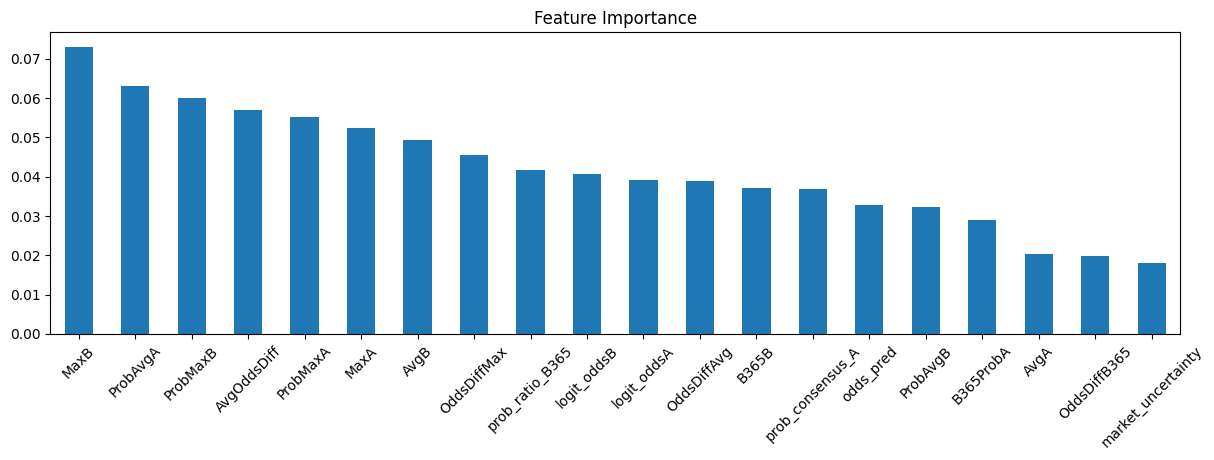

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

importances = pd.Series(rf.feature_importances_, index=X_train.columns)
importances.sort_values(ascending=False).head(20).plot(kind='bar', figsize=(12, 5))
plt.title('Feature Importance')
plt.tight_layout()
plt.xticks(rotation=45)
plt.show()

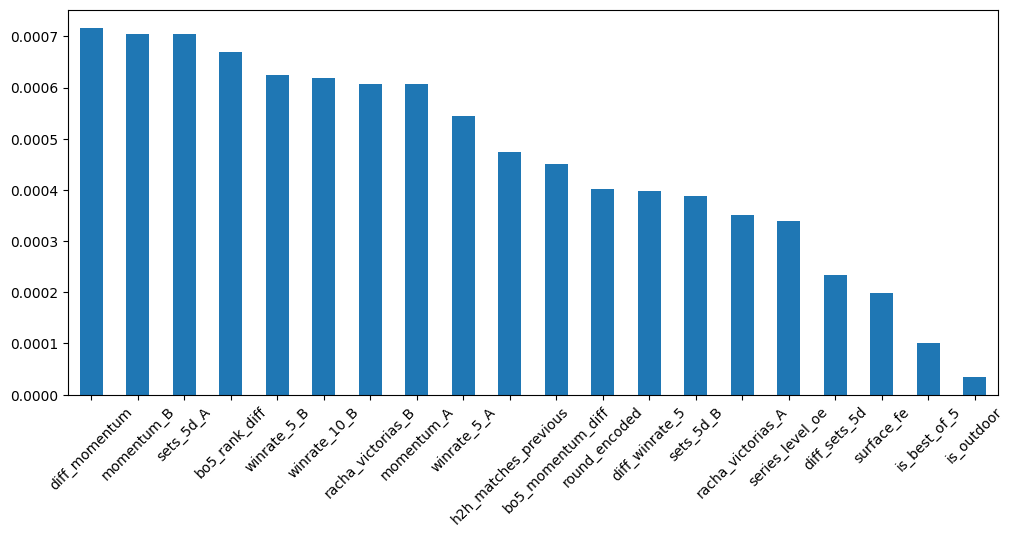

In [ ]:
importances.sort_values(ascending=False).tail(20).plot(kind='bar', figsize=(12, 5))
plt.xticks(rotation=45)
plt.show()

## Evaluación 2: Value Bets

In [ ]:
# Probabilidades calibradas del modelo
y_proba_rf_plus_lr = rf.predict_proba(X_test)

In [ ]:
def simular_apuestas(df, umbral_edge, monto=1):
    # Apuestas a A cuando tu modelo ve más valor que las odds
    bets_A = df[df['edge_A'] > umbral_edge].copy()
    bets_A['retorno'] = bets_A.apply(lambda r: (r['cuota_A'] - 1) * monto if r['y_true'] == 1 else -monto,axis=1)

    # Apuestas a B cuando tu modelo ve más valor que las odds
    bets_B = df[df['edge_B'] > umbral_edge].copy()
    bets_B['retorno'] = bets_B.apply(lambda r: (r['cuota_B'] - 1) * monto if r['y_true'] == 0 else -monto,axis=1)

    total_bets   = len(bets_A) + len(bets_B)
    total_retorno = bets_A['retorno'].sum() + bets_B['retorno'].sum()
    roi          = total_retorno / (total_bets * monto) * 100 if total_bets > 0 else 0

    print(f"Umbral edge: {umbral_edge:.2f}")
    print(f"  Apuestas a A: {len(bets_A)} | Apuestas a B: {len(bets_B)} | Total: {total_bets}")
    print(f"  ROI: {roi:.2f}% | Ganancia neta: {total_retorno:.2f}u")

for name, proba in [("Logistic Regression", y_proba_logreg[:, 1]),("Simplified Logistic Regression", y_proba_lr_simpl[:, 1]),
                    ("Random Forest", y_proba_rnd_clf[:, 1]),("XGBoost", y_proba_xgboost[:, 1]),("LGBM",y_proba_lgbm[:, 1]),
                     ("Random Forest plus Logistic Regression", y_proba_rf_plus_lr[:, 1])]:
  df_test = X_test.copy()
  df_test['y_true']       = y_test.values
  df_test['proba_modelo'] = proba
  df_test['proba_odds']   = df_test['B365ProbA']
  df_test['cuota_A']      = df_test['B365A']
  df_test['cuota_B']      = df_test['B365B']

  # Edge: diferencia entre tu modelo y el mercado
  df_test['edge_A'] = df_test['proba_modelo'] - df_test['B365ProbA']
  df_test['edge_B'] = (1 - df_test['proba_modelo']) - df_test['B365ProbB']

  print(f"Resultados para {name}:")
  for umbral in [0.02, 0.05, 0.07, 0.10, 0.15]:
      simular_apuestas(df_test, umbral, monto=1000)
  print()

Resultados para Logistic Regression:
Umbral edge: 0.02
  Apuestas a A: 1186 | Apuestas a B: 1321 | Total: 2507
  ROI: -11.34% | Ganancia neta: -284260.00u
Umbral edge: 0.05
  Apuestas a A: 838 | Apuestas a B: 939 | Total: 1777
  ROI: -12.95% | Ganancia neta: -230090.00u
Umbral edge: 0.07
  Apuestas a A: 655 | Apuestas a B: 754 | Total: 1409
  ROI: -12.56% | Ganancia neta: -177020.00u
Umbral edge: 0.10
  Apuestas a A: 434 | Apuestas a B: 501 | Total: 935
  ROI: -14.83% | Ganancia neta: -138670.00u
Umbral edge: 0.15
  Apuestas a A: 213 | Apuestas a B: 239 | Total: 452
  ROI: -21.85% | Ganancia neta: -98750.00u

Resultados para Simplified Logistic Regression:
Umbral edge: 0.02
  Apuestas a A: 423 | Apuestas a B: 934 | Total: 1357
  ROI: -2.75% | Ganancia neta: -37290.00u
Umbral edge: 0.05
  Apuestas a A: 28 | Apuestas a B: 26 | Total: 54
  ROI: -38.89% | Ganancia neta: -21000.00u
Umbral edge: 0.07
  Apuestas a A: 2 | Apuestas a B: 3 | Total: 5
  ROI: 560.00% | Ganancia neta: 28000.00u
Umb

Para el último modelo que fue el Random Forest + Logistic Regression:

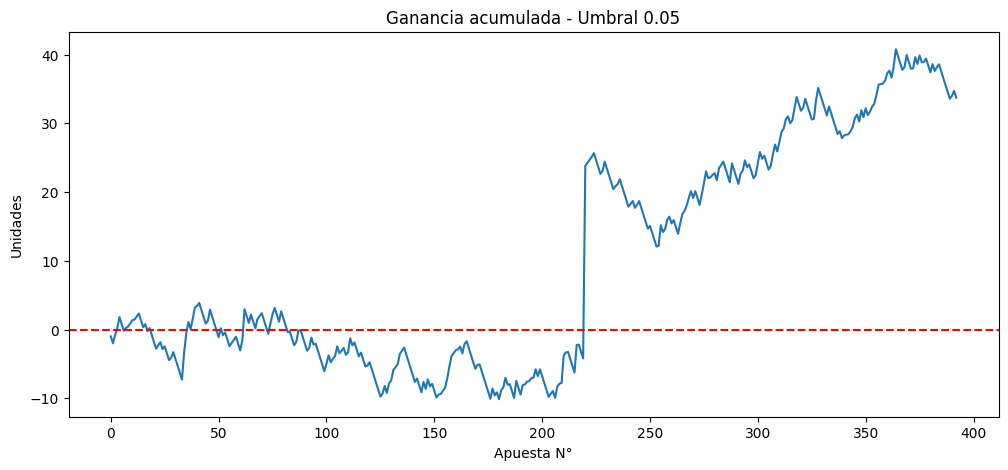

In [ ]:
bets_A = df_test[df_test['edge_A'] > 0.05].copy()
bets_B = df_test[df_test['edge_B'] > 0.05].copy()

bets_A['retorno'] = bets_A.apply(
    lambda r: (r['cuota_A'] - 1) if r['y_true'] == 1 else -1, axis=1)
bets_B['retorno'] = bets_B.apply(
    lambda r: (r['cuota_B'] - 1) if r['y_true'] == 0 else -1, axis=1)

# Combinar y ordenar por índice (que refleja orden temporal)
todas_bets = pd.concat([bets_A, bets_B]).sort_index()

# Curva acumulada
todas_bets['retorno'].cumsum().reset_index(drop=True).plot(figsize=(12, 5))
plt.axhline(0, color='red', linestyle='--')
plt.title('Ganancia acumulada - Umbral 0.05')
plt.xlabel('Apuesta N°')
plt.ylabel('Unidades')
plt.show()

In [ ]:
# Filtrar cuotas muy altas (favoritos abrumadores)
df_test_filtrado = df_test[(df_test['cuota_A'] < 5) & (df_test['cuota_B'] < 5)]

# Repetimos la simulación ahora con ese filtro
for name, proba in [("Logistic Regression", y_proba_logreg[:, 1]),("Simplified Logistic Regression", y_proba_lr_simpl[:, 1]),
                    ("Random Forest", y_proba_rnd_clf[:, 1]),("XGBoost", y_proba_xgboost[:, 1]),("LGBM",y_proba_lgbm[:, 1]),
                     ("Random Forest plus Logistic Regression", y_proba_rf_plus_lr[:, 1])]:
  df_test = X_test.copy()
  df_test['y_true']       = y_test.values
  df_test['proba_modelo'] = proba
  df_test['proba_odds']   = df_test['B365ProbA']
  df_test['cuota_A']      = df_test['B365A']
  df_test['cuota_B']      = df_test['B365B']

  # Edge: diferencia entre tu modelo y el mercado
  df_test['edge_A'] = df_test['proba_modelo'] - df_test['B365ProbA']
  df_test['edge_B'] = (1 - df_test['proba_modelo']) - df_test['B365ProbB']

  df_test = df_test[df_test.index.isin(df_test_filtrado.index)]

  print(f"Resultados para {name}:")
  for umbral in [0.02, 0.05, 0.07]:
      simular_apuestas(df_test, umbral, monto=1000)
  print()


Resultados para Logistic Regression:
Umbral edge: 0.02
  Apuestas a A: 915 | Apuestas a B: 1072 | Total: 1987
  ROI: -11.51% | Ganancia neta: -228750.00u
Umbral edge: 0.05
  Apuestas a A: 670 | Apuestas a B: 774 | Total: 1444
  ROI: -15.05% | Ganancia neta: -217370.00u
Umbral edge: 0.07
  Apuestas a A: 528 | Apuestas a B: 628 | Total: 1156
  ROI: -15.41% | Ganancia neta: -178170.00u

Resultados para Simplified Logistic Regression:
Umbral edge: 0.02
  Apuestas a A: 290 | Apuestas a B: 824 | Total: 1114
  ROI: 3.54% | Ganancia neta: 39390.00u
Umbral edge: 0.05
  Apuestas a A: 1 | Apuestas a B: 1 | Total: 2
  ROI: 100.00% | Ganancia neta: 2000.00u
Umbral edge: 0.07
  Apuestas a A: 1 | Apuestas a B: 1 | Total: 2
  ROI: 100.00% | Ganancia neta: 2000.00u

Resultados para Random Forest:
Umbral edge: 0.02
  Apuestas a A: 514 | Apuestas a B: 857 | Total: 1371
  ROI: -2.69% | Ganancia neta: -36870.00u
Umbral edge: 0.05
  Apuestas a A: 74 | Apuestas a B: 240 | Total: 314
  ROI: -0.25% | Ganancia 

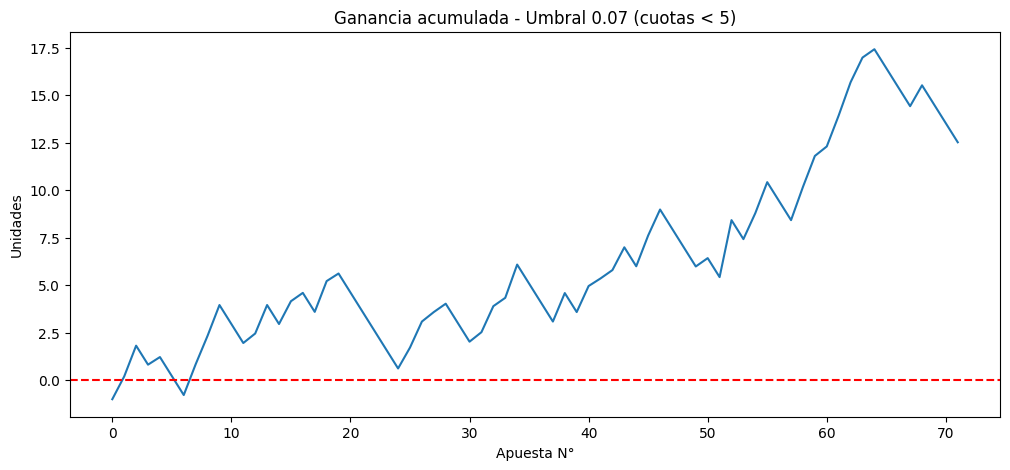

In [ ]:
# Curva acumulada filtrada
bets_A = df_test_filtrado[df_test_filtrado['edge_A'] > 0.07].copy()
bets_B = df_test_filtrado[df_test_filtrado['edge_B'] > 0.07].copy()

bets_A['retorno'] = bets_A.apply(
    lambda r: (r['cuota_A'] - 1) if r['y_true'] == 1 else -1, axis=1)
bets_B['retorno'] = bets_B.apply(
    lambda r: (r['cuota_B'] - 1) if r['y_true'] == 0 else -1, axis=1)

todas_bets = pd.concat([bets_A, bets_B]).sort_index()

todas_bets['retorno'].cumsum().reset_index(drop=True).plot(figsize=(12, 5))
plt.axhline(0, color='red', linestyle='--')
plt.title('Ganancia acumulada - Umbral 0.07 (cuotas < 5)')
plt.xlabel('Apuesta N°')
plt.ylabel('Unidades')
plt.show()

## Conclusión Notebook

Los modelos no mejoran el accuracy baseline.

Sí se muestran un poco mejores cuando comparamos las predicciones de más del 70% de confianza contra las apuestas que reflejan más de 70% de probabilidad.

En *value bets*, cuando difieren las predicciones de los modelos de las probabilidades reflejadas en las cuotas de mercado, apostar por nuestra predicción no es rentable, salvo en algunos escenarios donde sí se reportaron ROI positivos pero requieren de mayor examinación para determinar de que no se trata de casos aislados.